In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [35]:
X_train=np.load("X_train0.npy")
X_test=np.load("X_test0.npy")
y_train=np.load("y_train0.npy")
y_test=np.load("y_test0.npy")
coords_train = np.load("coords_train0.npy", allow_pickle=True)
coords_test  = np.load("coords_test0.npy", allow_pickle=True)


print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# X = np.load("X.npy")
# y = np.load("y.npy")

# print(X.shape, y.shape)

(60, 64, 64, 18) (60, 64, 64, 1)
(61, 64, 64, 18) (61, 64, 64, 1)


In [30]:
import numpy as np
from scipy.ndimage import gaussian_filter

# =========================
# CREATE DENSITY FOR PATCH
# =========================
def get_density_patch(coords, df_points, patch_size=64, sigma=10):

    # extract bounds
    lat1, lon1 = coords["top_left"]
    lat2, lon2 = coords["bottom_right"]

    lat_min, lat_max = min(lat1, lat2), max(lat1, lat2)
    lon_min, lon_max = min(lon1, lon2), max(lon1, lon2)

    # expand to 3× region
    lat_range = lat_max - lat_min
    lon_range = lon_max - lon_min

    lat_min -= lat_range
    lat_max += lat_range
    lon_min -= lon_range
    lon_max += lon_range

    # filter points in region
    subset = df_points[
        (df_points["Latitude"] >= lat_min) &
        (df_points["Latitude"] <= lat_max) &
        (df_points["Longitude"] >= lon_min) &
        (df_points["Longitude"] <= lon_max)
    ]

    # empty grid
    density = np.zeros((patch_size, patch_size), dtype=np.float32)

    if len(subset) == 0:
        return density[..., None]

    # map points → grid
    for _, row in subset.iterrows():
        r = int((row["Latitude"] - lat_min) / (lat_max - lat_min) * patch_size)
        c = int((row["Longitude"] - lon_min) / (lon_max - lon_min) * patch_size)

        if 0 <= r < patch_size and 0 <= c < patch_size:
            density[r, c] += 1

    # KDE smoothing
    density = gaussian_filter(density, sigma=sigma)

    # normalize
    if density.max() > 0:
        density /= density.max()

    return density[..., None]

def add_density(X, coords, df_points):

    X_new = []

    for i in range(len(X)):
        d_patch = get_density_patch(coords[i], df_points)

        patch = np.concatenate([X[i], d_patch], axis=2)
        X_new.append(patch)

    return np.array(X_new, dtype=np.float32)

In [36]:
import pandas as pd

df_points = pd.read_csv("Landslide_Inventory_Kerala_TN.csv")

X_train_n = add_density(X_train, coords_train, df_points)
X_test_n  = add_density(X_test, coords_test, df_points)

print(X_train_n.shape)

(60, 64, 64, 19)


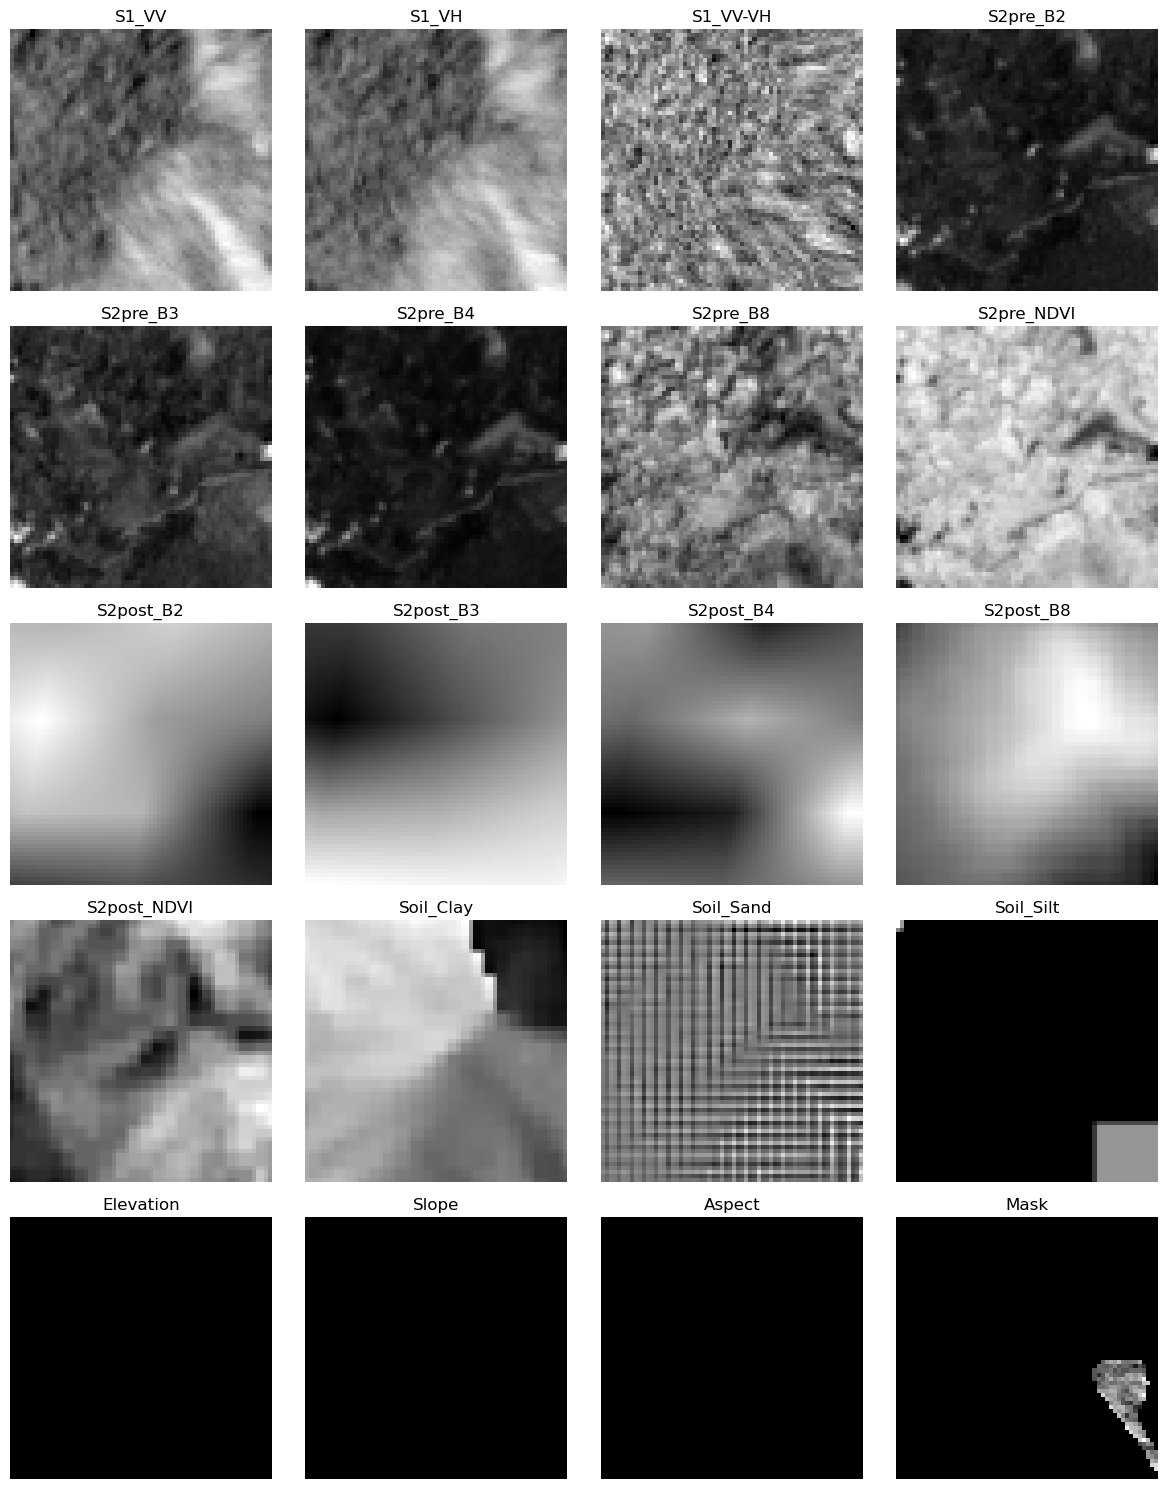

In [53]:
band_names_full = [
    "S1_VV", "S1_VH", "S1_VV-VH",

    "S2pre_B2", "S2pre_B3", "S2pre_B4", "S2pre_B8", "S2pre_NDVI",

    "S2post_B2", "S2post_B3", "S2post_B4", "S2post_B8", "S2post_NDVI",

    "Soil_Clay", "Soil_Sand", "Soil_Silt",

    "Elevation", "Slope", "Aspect", "Curvature", "Flow",

    "Rain_Avg", "Rain_Max"
]

keep = [i for i in range(len(band_names_full))]
band_names = [band_names_full[i] for i in keep]

import matplotlib.pyplot as plt

i = 0

X = X_train_n
y = y_train

num_bands = X.shape[3]
cols = 4
rows = (num_bands + 1 + cols - 1) // cols

plt.figure(figsize=(12, 3*rows))

for b in range(num_bands):
    plt.subplot(rows, cols, b + 1)
    plt.imshow(X[i][:,:,b], cmap='gray')
    plt.title(band_names[b])   # ✅ actual name
    plt.axis('off')

# Mask
plt.subplot(rows, cols, num_bands + 1)
plt.imshow(y[i][:,:,0], cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
threshold = 0.1  # adjust (try 0.01–0.05)

mask_fraction = y_train.reshape(y_train.shape[0], -1).sum(axis=1)

keep_idx = mask_fraction > threshold

X_train_filtered = X_train[keep_idx]
y_train_filtered = y_train[keep_idx]

print("Before:", X_train.shape[0])
print("After:", X_train_filtered.shape[0])


mask_fraction = y_test.reshape(y_test.shape[0], -1).sum(axis=1)

keep_idx = mask_fraction > threshold

X_test_filtered = X_test[keep_idx]
y_test_filtered = y_test[keep_idx]

print("Before:", X_test.shape[0])
print("After:", X_test_filtered.shape[0])

# mask_fraction = y.reshape(y.shape[0], -1).mean(axis=1)

# threshold = 0.02  # adjust (try 0.01–0.05)

# keep_idx = mask_fraction > threshold

# X_filtered = X[keep_idx]
# y_filtered = y[keep_idx]

# print("Before:", X.shape[0])
# print("After:", X_filtered.shape[0])


Before: 60
After: 59
Before: 61
After: 55


In [25]:
np.save('X_train_filtered.npy', X_train_filtered)
np.save('y_train_filtered.npy', y_train_filtered)

np.save('X_test_filtered.npy', X_test_filtered)
np.save('y_test_filtered.npy', y_test_filtered)